

# <u> EXPERIMENT 10 </p>
</u>
Name: Vrishali Sahay </br>
SAP ID: 590011701 </br>
Batch: 19 (AI/ML)




In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [ ]:
df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

In [ ]:
df_encoded = pd.get_dummies(df, columns=['species'], drop_first=True)

In [ ]:
X = df_encoded.drop(columns=[
    'species_versicolor',
    'species_virginica'
])

y = df_encoded[['species_versicolor', 'species_virginica']]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
y_train_labels = y_train.apply(
    lambda row: 'setosa' if row.sum() == 0 else row.idxmax(),
    axis=1
)

y_test_labels = y_test.apply(
    lambda row: 'setosa' if row.sum() == 0 else row.idxmax(),
    axis=1
)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_labels)

KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test_labels, y_pred))
print(classification_report(y_test_labels, y_pred))

Accuracy: 1.0
                    precision    recall  f1-score   support

            setosa       1.00      1.00      1.00        10
species_versicolor       1.00      1.00      1.00         9
 species_virginica       1.00      1.00      1.00        11

          accuracy                           1.00        30
         macro avg       1.00      1.00      1.00        30
      weighted avg       1.00      1.00      1.00        30



In [ ]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]
new_flower_scaled = scaler.transform(new_flower)

prediction = knn.predict(new_flower_scaled)
print("Predicted species:", prediction[0])

Predicted species: setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Convert class labels to numeric form for plotting
label_mapping = {
    'setosa': 0,
    'species_versicolor': 1,
    'species_virginica': 2
}

y_test_numeric = y_test_labels.map(label_mapping)
y_pred_numeric = pd.Series(y_pred).map(label_mapping)

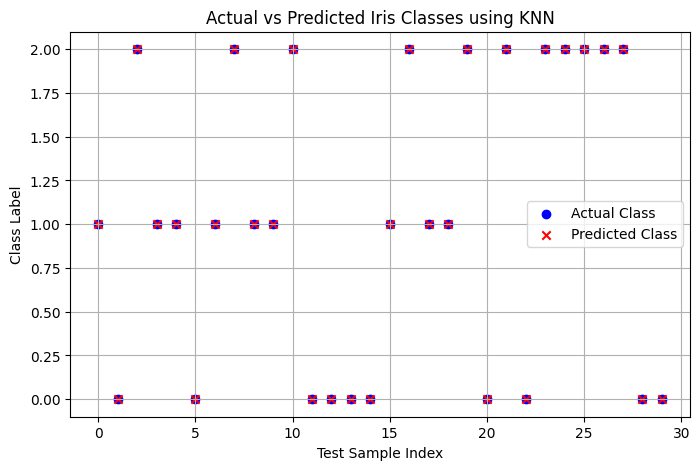

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(range(len(y_test_numeric)), y_test_numeric,
            color='blue', label='Actual Class', marker='o')

plt.scatter(range(len(y_pred_numeric)), y_pred_numeric,
            color='red', label='Predicted Class', marker='x')

plt.xlabel("Test Sample Index")
plt.ylabel("Class Label")
plt.title("Actual vs Predicted Iris Classes using KNN")
plt.legend()
plt.grid(True)
plt.show()